# Phase 1: Explorative Datenanalyse (EDA) & Preprocessing-Vorbereitung

## Ziele dieses Notebooks:
* **Rohdaten laden & Struktur verstehen:** Form des Datensatzes (`shape`), Datentypen (`dtypes`) und erste Zeilen prüfen.
* **Qualitätscheck:** Fehlende Werte (`missing values`), unmögliche Werte (z. B. negatives Alter oder unbekannte Kategorien) identifizieren.
* **Zielvariable analysieren:** Die Verteilung der Zielklasse (`target`) untersuchen und auf ein Klassenungleichgewicht (*Class Imbalance*) prüfen.
* **Cleaned Dataset exportieren:** Die bereinigten Daten als `data/data_processed.csv` abspeichern – dies bildet die Schnittstelle für das spätere Training in `modeling.ipynb`. 

In [68]:
import pandas as pd
import numpy as np

# Daten laden
df = pd.read_csv("data/data.csv")

# Erste Inspektion
print("Shape des Datensatzes:", df.shape)
df.head()

Shape des Datensatzes: (19719, 23)


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate


* **target hat 4 Unikate (unique = 4).  
* **Die häufigste Klasse ist Moderate mit 8.452 Einträgen (von insg. 19.719).   
* *** Das bestätigt eindeutig das vorhergesagte Klassenungleichgewicht (Class Imbalance): Moderate macht über 42 % aller Datenpunkte aus, während die anderen drei Typen deutlich seltener vorkommen. Genau deshalb werden wir später beim Modellieren nicht die einfache Accuracy als Metrik nutzen, sondern den F1-Macro-Score!  

In [69]:
# Allgemeiner Überblick über Datentypen und fehlende Werte
df.info()

# Statistische Übersicht aller Spalten
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 19719 entries, 0 to 19718
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   N6      19719 non-null  int64
 1   N8      19719 non-null  int64
 2   N7      19719 non-null  int64
 3   N1      19719 non-null  int64
 4   N9      19719 non-null  int64
 5   N10     19719 non-null  int64
 6   N3      19719 non-null  int64
 7   N5      19719 non-null  int64
 8   E3      19719 non-null  int64
 9   N2      19719 non-null  int64
 10  E5      19719 non-null  int64
 11  N4      19719 non-null  int64
 12  E7      19719 non-null  int64
 13  E4      19719 non-null  int64
 14  age     19719 non-null  int64
 15  C4      19719 non-null  int64
 16  E1      19719 non-null  int64
 17  A4      19719 non-null  int64
 18  E10     19719 non-null  int64
 19  E9      19719 non-null  int64
 20  gender  19695 non-null  str  
 21  hand    19619 non-null  str  
 22  target  19719 non-null  str  
dtypes: int64(20), str(3)
m

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,...,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19695,19619,19719
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,Right,Moderate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11985,17424,8452
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,...,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275,NaN,NaN,NaN
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,...,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,...,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000,NaN,NaN,NaN
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,...,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000,NaN,NaN,NaN
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,...,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000,NaN,NaN,NaN


In [70]:
# Verteilung der 4 Persönlichkeitstypen
print("Absolute Verteilung des Targets:")
print(df["target"].value_counts())

print("\nProzentuale Verteilung:")
print(df["target"].value_counts(normalize=True).round(4) * 100)

Absolute Verteilung des Targets:
target
Moderate           8452
Resilient          6163
Overcontroller     2829
Undercontroller    2275
Name: count, dtype: int64

Prozentuale Verteilung:
target
Moderate           42.86
Resilient          31.25
Overcontroller     14.35
Undercontroller    11.54
Name: proportion, dtype: float64


## Explizite Prüfung auf 'Missing Values
* **'Best Practice' (obwohl der Datensatz sehr gut aussieht)
* ** Imputation erfolgt erst in der modeling.ipynb um DataLeakage zwischen Train- und Testdaten zu vermeiden


In [71]:
# Explizite Prüfung auf fehlende Werte (Missing Values) pro Spalte
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing_values, "Percentage (%)": missing_percent})
missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Percentage (%)
gender,24,0.12
hand,100,0.51


## Visualisierungen zur Prüfung und für die Präsentatsion
#### Diese Grafik zeigt die Class Imbalance (warum wir den F1-Score braucht)

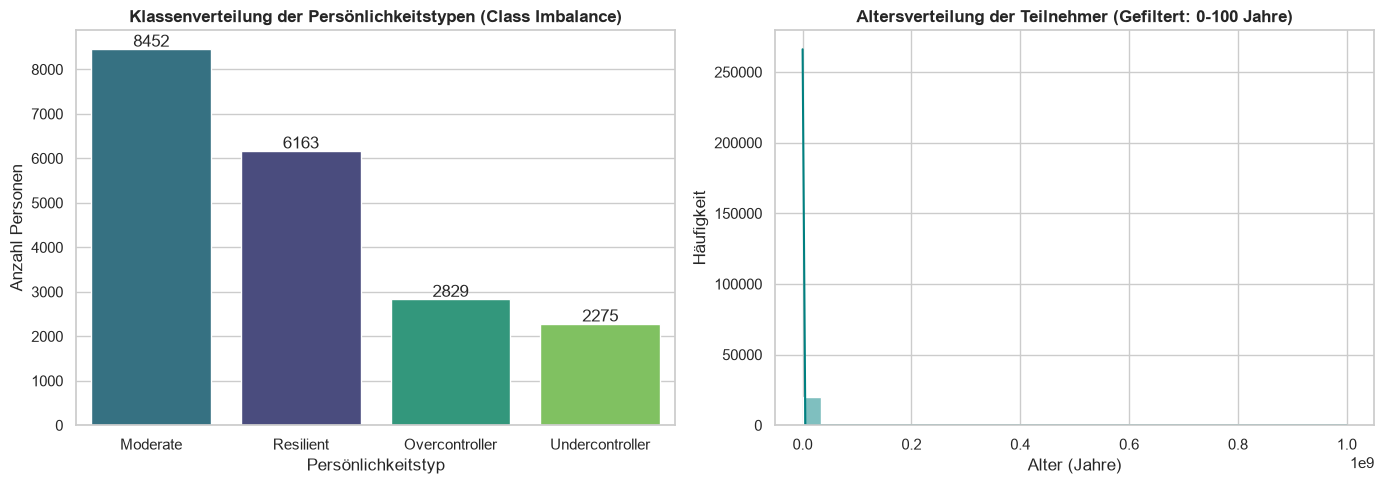

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target-Verteilung (Zeigt die Class Imbalance)
sns.countplot(
    data=df, 
    x="target", 
    ax=axes[0], 
    order=df["target"].value_counts().index,
    hue='target',
    palette="viridis"
)
axes[0].set_title("Klassenverteilung der Persönlichkeitstypen (Class Imbalance)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Persönlichkeitstyp")
axes[0].set_ylabel("Anzahl Personen")

# Absolute Zahlen über den Balken anzeigen
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plot 2: Altersverteilung
sns.histplot(df["age"], bins=30, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Altersverteilung der Teilnehmer (Gefiltert: 0-100 Jahre)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Alter (Jahre)")
axes[1].set_ylabel("Häufigkeit")

plt.tight_layout()
plt.savefig("data/eda_plots.png", dpi=300)
plt.show()

* **Der Datensatz wurde auf unplausible Ausreißer oder beschädigte Zeilen geprüft, ist von den Ausreiße beim Alter bereinigt und bereit für die Scikit-Learn Preprocessing Pipeline in modeling.ipynb.

#### Da extreme Aussreißer in den Daten stecken (Werte bis zu 1 Milliarde) werden diese Zeilen über das Alter herusgefiltert

In [73]:
# 1. Temporären gefilterten View/Datensatz erstellen (ohne das Original 'df' zu verändern)
df_clean = df[(df["age"] > 0) & (df["age"] <= 100)]

# 2. Differenz der Zeilen berechnen
count_cleaned = len(df) - len(df_clean)
percent_cleaned = (count_cleaned / len(df)) * 100

# 3. Ergebnis zur Entscheidungsgrundlage ausgeben
print(f"Es werden {count_cleaned} Zeilen ({percent_cleaned:.2f}%) mit irregulärem Alter identifiziert.")

# 4. Entscheidungslogik (Beispiel für den weiteren Ablauf)
if percent_cleaned > 5.0:
    print("⚠️ Warnung: Mehr als 5% der Daten betroffen! Filterung sollte überdacht werden (z. B. Imputation mit Median/Mean nutzen).")
else:
    print("✅ Anteil gering (< 5%). Zeilen können gefiltert oder im Preprocessing behandelt werden.")

Es werden 83 Zeilen (0.42%) mit irregulärem Alter identifiziert.
✅ Anteil gering (< 5%). Zeilen können gefiltert oder im Preprocessing behandelt werden.


In [77]:
# Das gesamte DataFrame filtern (behält nur Zeilen mit gültigem Alter)
# Index direkt neu ordnen. Spart auch wieder Speicherplatz
df = df[(df["age"] > 0) & (df["age"] <= 100)].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19636 entries, 0 to 19635
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   N6      19636 non-null  int64
 1   N8      19636 non-null  int64
 2   N7      19636 non-null  int64
 3   N1      19636 non-null  int64
 4   N9      19636 non-null  int64
 5   N10     19636 non-null  int64
 6   N3      19636 non-null  int64
 7   N5      19636 non-null  int64
 8   E3      19636 non-null  int64
 9   N2      19636 non-null  int64
 10  E5      19636 non-null  int64
 11  N4      19636 non-null  int64
 12  E7      19636 non-null  int64
 13  E4      19636 non-null  int64
 14  age     19636 non-null  int64
 15  C4      19636 non-null  int64
 16  E1      19636 non-null  int64
 17  A4      19636 non-null  int64
 18  E10     19636 non-null  int64
 19  E9      19636 non-null  int64
 20  gender  19612 non-null  str  
 21  hand    19538 non-null  str  
 22  target  19636 non-null  str  
dtypes: int64(20), str(3)
m

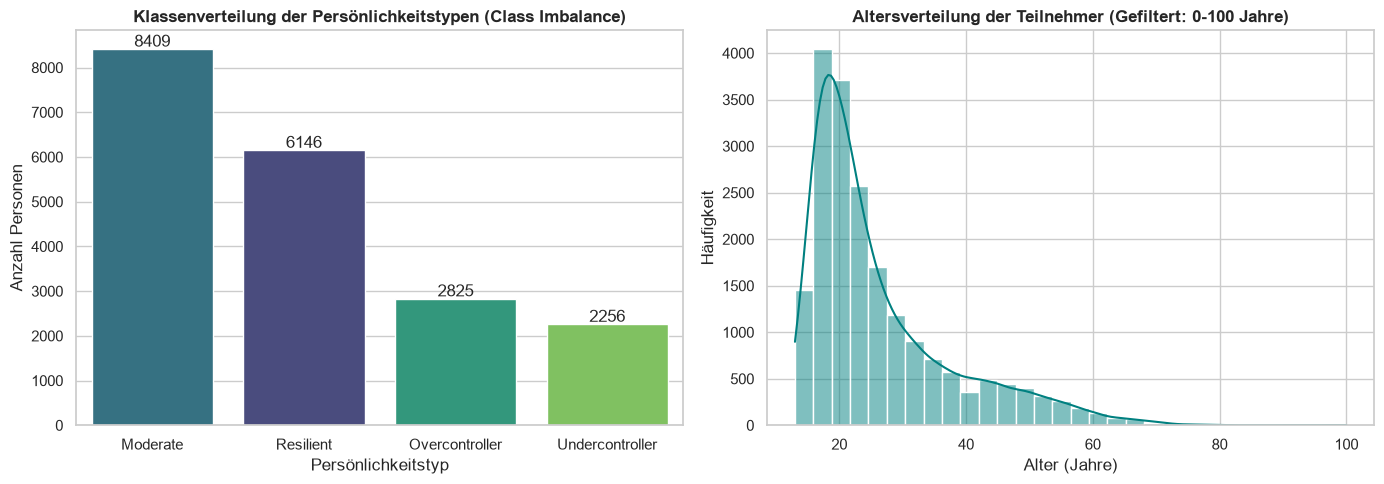

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target-Verteilung (Zeigt die Class Imbalance)
sns.countplot(
    data=df, 
    x="target", 
    ax=axes[0], 
    order=df["target"].value_counts().index,
    hue='target',
    palette="viridis"
)
axes[0].set_title("Klassenverteilung der Persönlichkeitstypen (Class Imbalance)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Persönlichkeitstyp")
axes[0].set_ylabel("Anzahl Personen")

# Absolute Zahlen über den Balken anzeigen
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plot 2: Altersverteilung
sns.histplot(df["age"], bins=30, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Altersverteilung der Teilnehmer (Gefiltert: 0-100 Jahre)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Alter (Jahre)")
axes[1].set_ylabel("Häufigkeit")

plt.tight_layout()
plt.savefig("data/eda_plots.png", dpi=300)
plt.show()

In [79]:
# Nun den aufbereiteten/bereinigten Datensatz exportieren
df.to_csv("data/data_processed.csv", index=False)
print("data/data_processed.csv wurde erfolgreich gespeichert!")

data/data_processed.csv wurde erfolgreich gespeichert!
